# 实验 15：使用 Stable-Baselines3 和 TensorBoard 进行基准测试

## 引言

在本次实验中，你将从**手动实现强化学习算法**过渡到使用 **Stable-Baselines3（SB3）** 和 **TensorBoard** 构建一个**标准化、研究级别的深度强化学习工作流程**。

在之前的实验中，你已经从零开始实现了 **TRPO** 和 **PPO** 等算法，以理解它们的数学基础、优化目标和实现细节。虽然这种底层实现对于建立直觉非常重要，但在现代强化学习研究和实际应用中，人们几乎总是依赖经过充分测试的算法库和系统化的实验日志工具。

本实验旨在弥合这两者之间的差距，介绍一种实用且可复现的强化学习实验流程。

## 使用 Stable-Baselines3

Stable-Baselines3（SB3）是一个被广泛使用的 Python 库，提供了**可靠且标准化的现代强化学习算法实现**。与其手动实现训练循环、rollout buffer 和优化步骤，SB3 使你能够将注意力集中在**算法选择、超参数调节和实验分析**上。

使用 SB3 通常遵循一个简单的工作流程：

1. **创建环境**（通常使用向量化环境，以便更高效地收集数据）
2. **实例化模型**，选择具体的算法和策略类型
3. **使用固定数量的时间步训练模型**
4. **保存、加载并评估**训练好的策略
5. **使用 TensorBoard 监控训练过程**

In [2]:
import sys
print(sys.executable)
import torch
print(torch.__version__)
print(torch.cuda.is_available())


d:\MiniConda\envs\atari\python.exe
2.11.0+cu128
True


In [3]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import CheckpointCallback
import os
import torch

ENV_ID = "Hopper-v4"
SEED = 42
N_ENVS = 8
TOTAL_TIMESTEPS = 2_000_000
SAVE_FREQ = 100_000


CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

vec_env = make_vec_env(
    ENV_ID,
    n_envs=N_ENVS,
    seed=SEED,
)

checkpoint_callback = CheckpointCallback(
    save_freq=SAVE_FREQ,
    save_path=CHECKPOINT_DIR,
    name_prefix="ppo_hopper"
)


policy_kwargs = dict(
    activation_fn=torch.nn.Tanh,            
    net_arch=dict(pi=[256, 256], vf=[256, 256])  
)

model = PPO(
    "MlpPolicy",
    vec_env,
    policy_kwargs=policy_kwargs,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=1,
    tensorboard_log = "./tb_logs"
)


model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=checkpoint_callback,
    tb_log_name="PPO_Hopper_base"
)

# 最终模型（再存一次）
model.save("ppo_hopper_final")

vec_env.close()

d:\MiniConda\envs\atari\lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Using cuda device
Logging to ./tb_logs\PPO_Hopper_base_5


d:\MiniConda\envs\atari\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 18.8     |
|    ep_rew_mean     | 14.6     |
| time/              |          |
|    fps             | 2862     |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 16384    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 24          |
|    ep_rew_mean          | 26          |
| time/                   |             |
|    fps                  | 2052        |
|    iterations           | 2           |
|    time_elapsed         | 15          |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.013602817 |
|    clip_fraction        | 0.208       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.22       |
|    explained_variance   | -0.0453     |
|    learning_rate        | 0.

为了监控训练进度，可以在项目目录下运行以下命令来启动 TensorBoard：

`tensorboard --logdir tb_logs`

该命令会启动一个本地 Web 服务器，通常地址为 `http://localhost:6006`，用于可视化训练过程中生成的日志。每一次运行都会作为一个单独的条目显示，并且可以被启用或禁用，以便进行对比。

TensorBoard 允许你查看 episode reward、loss 项以及训练速度等学习曲线，因此它是分析强化学习训练过程的重要工具。

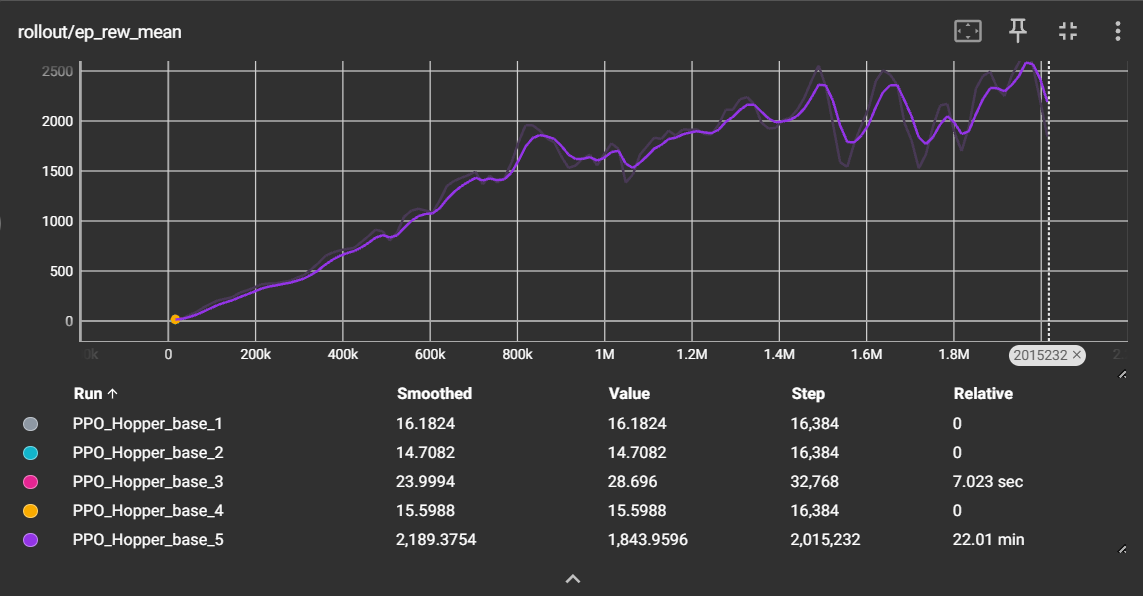

## 算法比较任务

在本实验的这一部分中，你将使用 **Stable-Baselines3** 来求解同一个连续控制任务，并比较四种不同的强化学习算法：**PPO、TRPO、DDPG 和 SAC**。所有算法都应在**一致的实验设置**下进行训练，包括相同的环境、可比较的网络结构，以及固定的训练步数预算。

你需要使用 **TensorBoard** 记录所有训练过程，并通过**绘制 episode reward 曲线**来比较它们的性能。通过这一比较，你应该分析不同算法在学习速度、训练稳定性和最终性能上的差异。本任务的目标不仅是判断哪种算法表现最好，还要理解*为什么*不同的算法设计会导致不同的学习行为。



In [ ]:
## your time to work on it
import gymnasium as gym
from stable_baselines3 import PPO, A2C, SAC, TD3
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
import torch

ENV_ID = "Hopper-v4"
SEED = 42
TOTAL_TIMESTEPS = 500_000  # 为了比较快，先用 50 万步，正式可以调大

# 每个算法的配置
# 注意：Hopper 是连续控制环境，不能用 DQN 这类离散算法
algorithms = {
    "PPO": {
        "model_class": PPO,
        "env": make_vec_env(ENV_ID, n_envs=8, seed=SEED),
        "kwargs": {
            "policy": "MlpPolicy",
            "learning_rate": 3e-4,
            "n_steps": 2048,
            "batch_size": 256,
            "n_epochs": 10,
            "gamma": 0.99,
            "gae_lambda": 0.95,
            "clip_range": 0.2,
            "verbose": 1,
            "tensorboard_log": "./tb_logs_compare",
            "device": "cuda",
        },
    },
    "A2C": {
        "model_class": A2C,
        "env": make_vec_env(ENV_ID, n_envs=8, seed=SEED),
        "kwargs": {
            "policy": "MlpPolicy",
            "learning_rate": 7e-4,
            "n_steps": 5,
            "gamma": 0.99,
            "gae_lambda": 0.95,
            "verbose": 1,
            "tensorboard_log": "./tb_logs_compare",
            "device": "cuda",
        },
    },
    "SAC": {
        "model_class": SAC,
        "env": gym.make(ENV_ID),  # SAC 用单环境
        "kwargs": {
            "policy": "MlpPolicy",
            "learning_rate": 3e-4,
            "buffer_size": 1_000_000,
            "batch_size": 256,
            "gamma": 0.99,
            "tau": 0.005,
            "verbose": 1,
            "tensorboard_log": "./tb_logs_compare",
            "device": "cuda",
        },
    },
    "TD3": {
        "model_class": TD3,
        "env": gym.make(ENV_ID),  # TD3 用单环境
        "kwargs": {
            "policy": "MlpPolicy",
            "learning_rate": 3e-4,
            "buffer_size": 1_000_000,
            "batch_size": 256,
            "gamma": 0.99,
            "tau": 0.005,
            "verbose": 1,
            "tensorboard_log": "./tb_logs_compare",
            "device": "cuda",
        },
    },
}

results = {}

for name, config in algorithms.items():
    print(f"\n{'='*40}")
    print(f"开始训练: {name}")
    print(f"{'='*40}")
    
    model = config["model_class"](
        env=config["env"],
        **config["kwargs"]
    )
    
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        tb_log_name=name,
        reset_num_timesteps=True,
    )
    
    # 保存模型
    model.save(f"compare_{name.lower()}_hopper")
    
    # 评估最终性能
    mean_reward, std_reward = evaluate_policy(
        model, 
        config["env"], 
        n_eval_episodes=10, 
        deterministic=True
    )
    results[name] = {
        "mean_reward": mean_reward,
        "std_reward": std_reward,
    }
    print(f"{name} 最终评估 | 平均 Reward: {mean_reward:.1f} ± {std_reward:.1f}")

# 关闭环境
for config in algorithms.values():
    config["env"].close()

# 打印对比结果
print("\n" + "="*40)
print("算法对比结果")
print("="*40)
for name, res in results.items():
    print(f"{name:10s} | Reward: {res['mean_reward']:8.1f} ± {res['std_reward']:.1f}")
